# Data gap: `local_authority_district` is (almost) never populated

Discovered by the agent itself during the Task 9 evaluation run (Q4/Q5: "Which local
authority had the highest number of fatal collisions last year? And what about the
year before that?") — see `testing.ipynb` for the full reconstructed transcript. The
agent's first query returned nulls, so it ran several diagnostic queries on its own
initiative and worked out why.

This notebook demonstrates the underlying data fact directly against
`data/road_safety.db`, independent of the agent.

In [1]:
import sqlite3

import pandas as pd

DB_PATH = "data/road_safety.db"

conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
coverage = pd.read_sql_query(
    """
    SELECT
        collision_year,
        COUNT(*) AS total_collisions,
        SUM(local_authority_district IS NOT NULL) AS district_populated,
        SUM(local_authority_highway IS NOT NULL) AS highway_populated,
        SUM(local_authority_ons_district IS NOT NULL) AS ons_populated
    FROM collision
    GROUP BY collision_year
    ORDER BY collision_year
    """,
    conn,
)
conn.close()
coverage

,collision_year,total_collisions,district_populated,highway_populated,ons_populated
0,2021,101087,194,101087,101087
1,2022,106004,0,106004,106004
2,2023,104258,0,104258,104258
3,2024,100927,0,100927,100927
4,2025,101525,0,101525,101525


**Reading this table:** `local_authority_district` (the field with readable names, e.g.
"Stockton-on-Tees") is populated for only 194 of 101,087 collisions in 2021, and 0 in
every other year. `local_authority_highway` and `local_authority_ons_district` (ONS
codes, e.g. "E10000019") are fully populated for every year. So for any year other than
2021, the agent can identify *which* local authority via the code, but can't give a
readable name from this database alone — which is exactly what it told the user in
Q4/5, rather than fabricating a name.

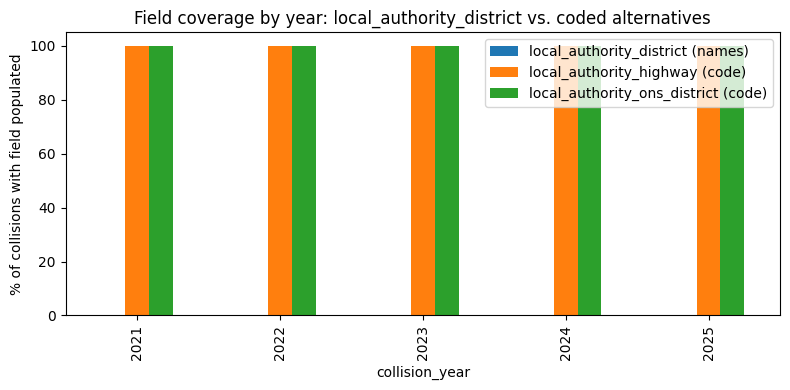

In [2]:
import matplotlib.pyplot as plt

coverage_pct = coverage.set_index("collision_year")[
    ["district_populated", "highway_populated", "ons_populated"]
].div(coverage.set_index("collision_year")["total_collisions"], axis=0) * 100

ax = coverage_pct.plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("% of collisions with field populated")
ax.set_xlabel("collision_year")
ax.set_title("Field coverage by year: local_authority_district vs. coded alternatives")
ax.legend(["local_authority_district (names)", "local_authority_highway (code)", "local_authority_ons_district (code)"])
plt.tight_layout()
plt.show()

## Takeaway

This is a gap in `full_ingestion.ipynb`'s decoding step, not an agent defect: the
coded fields (`local_authority_highway`, `local_authority_ons_district`) are ONS
codes, and nothing in the current pipeline maps them to readable local authority
names for years other than the small 2021 subset. Two options if this is worth
fixing:

1. Add an ONS code → local authority name lookup to the ingestion pipeline (DfT
   publishes this mapping) and decode `local_authority_highway`/`ons_district` for
   all years, the same way other coded fields are already decoded.
2. Leave it as-is and treat "I can only give you the code" as acceptable agent
   behaviour for this question — arguably still correct, just less useful.